# Uganda YOP — Exploratory Analysis

> *Youth Opportunities Program (YOP)* — Northern Uganda, 2008.
> Replication data from Blattman, Fiala & Martinez (QJE 2014) and Jerzak, Johansson & Daoud (PMLR 2023).

## Programme

**YOP** was a government cash-grant programme awarding capital to self-organised groups of unemployed young adults in post-conflict Northern Uganda, intended to help them start skilled trades.

| Design element | Detail |
|---|---|
| Regions | Karamoja, Teso, Lango, West Nile sub-regions |
| Randomisation unit | **Applicant group** (~15-20 self-selected members each), not the individual |
| Sample | 535 groups, ~3,142 sampled individuals, 331 distinct satellite sites |
| Treatment rate | ~44% of groups |
| Primary outcome | log(skilled-labor hours/week + 100), 2-4 years post-treatment |

**SUTVA note.** Members of the same group share treatment status and plausibly influence each other (they train and start businesses together). Analyzing at the *individual* level risks violating the no-interference assumption; analyzing at the **group** level — the true randomization unit — avoids it by construction. This notebook works at group level throughout.

## Research questions

1. **Average Effect** — did YOP raise skilled-labor engagement?
2. **Effect Heterogeneity** — for whom, or under which conditions, is the effect stronger? "Conditions" spans group demographics/composition, language group, and satellite-derived landscape features — no single modality is assumed to matter more a priori.

This notebook explores the data and identification strategy behind both questions. Whether any candidate condition actually modifies the effect is what NEXIS searches for, in `src/apps/uganda/analyze.py`.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import sys; sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display as ipy_display
from pathlib import Path
from scipy import stats

from src.apps.uganda.data import (
    load_basemap, plot_districts, plot_languages,
    load_satellite_covariates, plot_boxplot_by_arm, plot_boxplot_by_district,
    plot_site_choropleth, LANG_NAMES, resolve_outcome, outcome_display,
    TREAT_COLOR, CTRL_COLOR,
)
from src.apps.uganda.analyze import aggregate_to_groups, build_covariates
from src.apps.covariates import Covariate, Level, Origin, Support

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
DATA_DIR    = Path('../data/uganda')
RESULTS_DIR = Path('../results/uganda/prithvi_l5_1024')

OUTCOME = 'log_skilled_hours'   # primary outcome (Blattman et al. 2014, Table III)
csv_col = resolve_outcome(OUTCOME)

df_raw = pd.read_csv(DATA_DIR / 'UgandaDataProcessed.csv', low_memory=False)
df_raw = df_raw.rename(columns={'Wobs': 'T', csv_col: 'Y'})
for col in ['lang_group', 'district']:
    df_raw[col] = df_raw[col].astype('category')

# Individual-level rows, restricted to those with a linked satellite image
# (needed for aggregate_to_groups()'s API and to match the NEXIS sample exactly).
individual_features = np.load(RESULTS_DIR / 'individual_features.npz')['features']
keep = (df_raw['Y'].notna() & np.isfinite(individual_features[:, 0])).values
df_individual = df_raw[keep].reset_index(drop=True)

# Group-level working frame: the true randomization unit (535 applicant
# groups). Reuses analyze.py's own aggregation so this notebook's numbers
# match the NEXIS pipeline exactly (age/female/educ averaged per group;
# group_female/karamojan_district/lang_group/district constant within group).
df, _ = aggregate_to_groups(df_individual, individual_features[keep])
W_df  = build_covariates(df)   # age, female, father_educ, mother_educ, group_female, lang_1..lang_7
df    = df.join(W_df.filter(like='lang_'))   # one-hot language dummies, for the explorer below

## Data sources

| Source | Level | Covariates | Notes |
|---|---|---|---|
| YOP applicant survey | Group (individual traits averaged) | age, female, father's/mother's education | Aggregated to the group mean — the analysis unit |
| YOP applicant survey | Group (constant within group) | group_female, karamojan_district, language (7 one-hot) | Genuinely group-level by design |
| Satellite imagery (Landsat, Prithvi-EO embeddings + SAE) | Site (geographic) | 6 spectral indices + neurons active in ≥ 5/331 sites | 331 unique satellite sites — a site can host multiple groups, so this is a coarser geography than the group itself |

The satellite block uses `load_satellite_covariates()` — spectral means and already-computed SAE activations (`results/uganda/prithvi_l5_1024/`) read directly off disk, no foundation-model forward pass — mirroring `src/apps/ghana/data.py`'s loader of the same name.

Groups          : 439  (T=193, C=246)
Individuals used: 2,082
Satellite sites : 331
Covariates      : 13 group-level (+karamojan_district), 152 site-level (satellite)


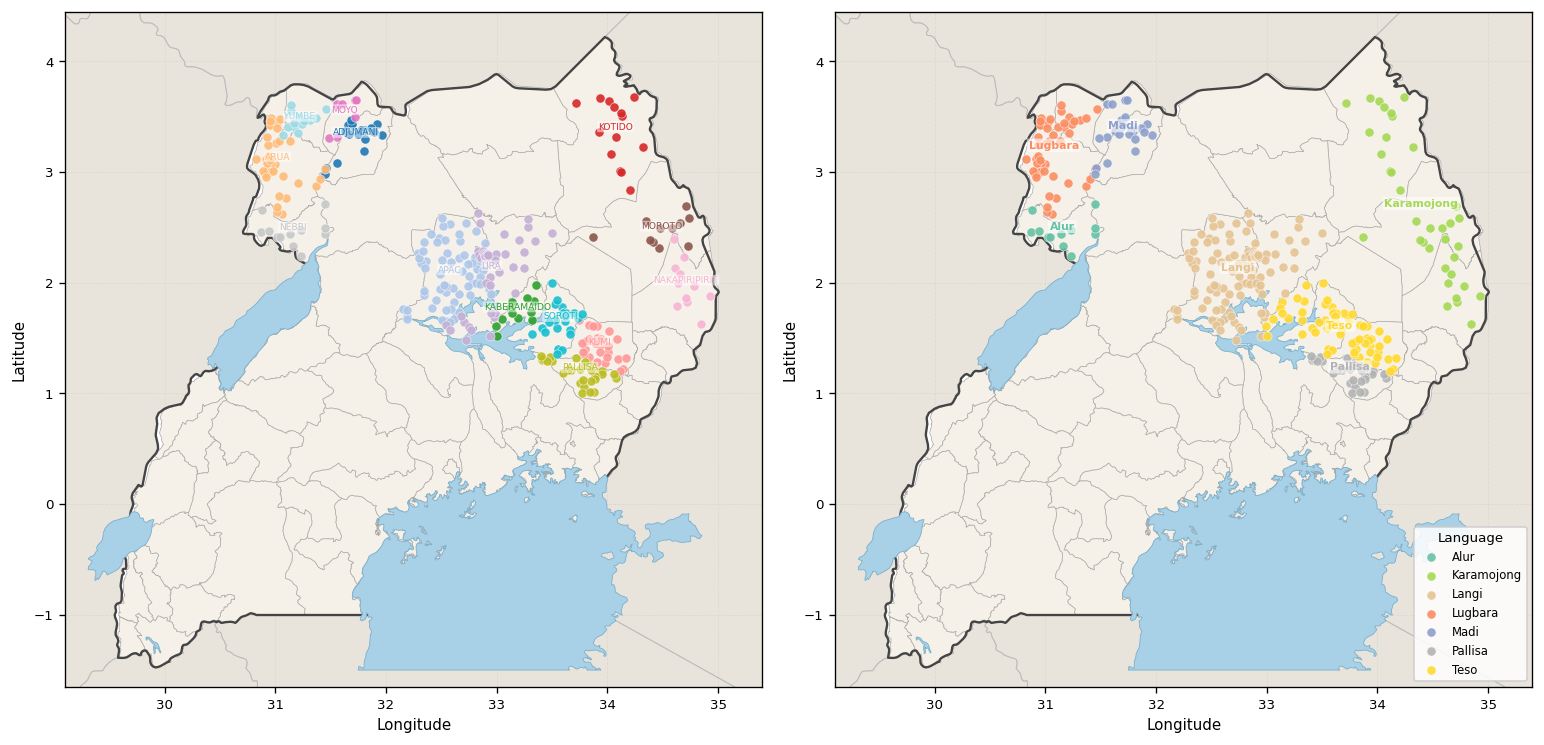

In [2]:
site_df, sat_covariates = load_satellite_covariates(DATA_DIR, RESULTS_DIR)

sites_geo = (
    df_raw.dropna(subset=['geo_long_center', 'geo_lat_center'])
          .groupby('geo_long_lat_key')
          .agg(lat=('geo_lat_center', 'first'), lon=('geo_long_center', 'first'),
               district=('district', 'first'),
               geo_long_center=('geo_long_center', 'first'), geo_lat_center=('geo_lat_center', 'first'))
)
site_geo_df = sites_geo.join(site_df, how='left')

uganda_gdf, neighbors, lakes_c, regions_gdf = load_basemap(DATA_DIR / 'map')

print(f'Groups          : {df["groupid"].nunique():,}  (T={int(df["T"].sum())}, C={int((1 - df["T"]).sum())})')
print(f'Individuals used: {len(df_individual):,}')
print(f'Satellite sites : {site_geo_df.shape[0]}')
print(f'Covariates      : {len(W_df.columns) + 1} group-level (+karamojan_district), '
      f'{len(sat_covariates)} site-level (satellite)')

fig, axes = plt.subplots(1, 2, figsize=(13, 6.5))
plot_districts(df_individual, uganda_gdf, neighbors, lakes_c, cities=regions_gdf, ax=axes[0])
plot_languages(df_individual, uganda_gdf, neighbors, lakes_c, cities=regions_gdf, ax=axes[1])
plt.tight_layout()
plt.show()

## Identification strategy

YOP is a **group-randomized RCT** — no discontinuity design to worry about, unlike Ghana. Treatment was randomized at the group level, so the average treatment effect is identified under standard RCT assumptions (SUTVA + random assignment), with no further conditioning needed. The one design choice that matters for identification is analysis **level**: working at the group level (as this notebook does) avoids the within-group interference that individual-level analysis would risk (see the SUTVA note above).

The checkable implication, since there is no running variable to inspect: **covariate balance** — pre-treatment group characteristics should be similar across arms.

In [3]:
rows = []
for col in ['age', 'female', 'father_educ', 'mother_educ', 'group_female', 'karamojan_district']:
    s0 = df.loc[df['T'] == 0, col].dropna()
    s1 = df.loc[df['T'] == 1, col].dropna()
    pooled_sd = np.sqrt((s0.var() + s1.var()) / 2)
    smd = (s1.mean() - s0.mean()) / pooled_sd if pooled_sd > 0 else 0.0
    _, pval = stats.ttest_ind(s0, s1, equal_var=False)
    rows.append({'variable': col, 'C mean': round(s0.mean(), 3), 'T mean': round(s1.mean(), 3),
                 'SMD': round(smd, 3), 'p-value': round(pval, 3),
                 'balanced (p>.05)': '✓' if pval > 0.05 else '✗'})
print('Covariate balance across arms (group level):')
display(pd.DataFrame(rows).set_index('variable'))

crosstab = pd.crosstab(df['lang_group'], df['T']).dropna()
chi2, p_lang, _, _ = stats.chi2_contingency(crosstab)
print(f"\nLanguage-group balance (chi-square across the 7 language groups): p = {p_lang:.3f}")

Covariate balance across arms (group level):


,C mean,T mean,SMD,p-value,balanced (p>.05)
variable,,,,,
age,24.979,25.356,0.105,0.275,✓
female,0.345,0.324,-0.069,0.478,✓
father_educ,3.273,3.149,-0.102,0.291,✓
mother_educ,2.136,2.025,-0.119,0.218,✓
group_female,0.407,0.381,-0.108,0.261,✓
karamojan_district,0.102,0.145,0.131,0.179,✓



Language-group balance (chi-square across the 7 language groups): p = 0.003


**A note on language balance.** Unlike every other covariate above, language-group composition is *not* balanced across arms (p = 0.003) — some language groups are noticeably over- or under-represented in Treatment vs. Comparison. This likely reflects randomization being stratified by sub-region rather than a failure of randomization itself (language and sub-region are closely tied — see the map above), but it means language shouldn't be read as a clean, orthogonal effect modifier: any language-group heterogeneity NEXIS finds could partly reflect this baseline imbalance rather than a genuine interaction. Worth keeping in mind when interpreting the Effect Heterogeneity explorer below.

## Average Effect

Estimand: **ATE = E[Y(1) − Y(0)]**, the average causal effect of YOP on log(skilled-labor hours/week + 100), at the group level. Identified directly under group-level randomization (no further adjustment required).

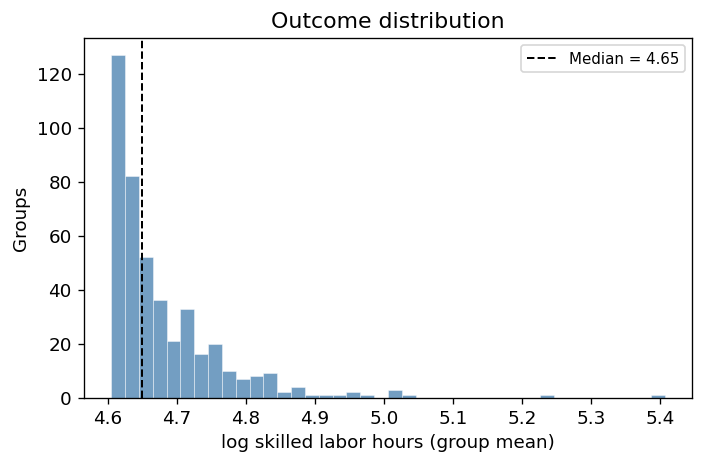

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(df['Y'], bins=40, color=CTRL_COLOR, alpha=0.85, edgecolor='white', lw=0.3)
ax.axvline(df['Y'].median(), color='black', lw=1.2, ls='--',
           label=f'Median = {df["Y"].median():.2f}')
ax.set_xlabel(f'{outcome_display(OUTCOME)} (group mean)')
ax.set_ylabel('Groups')
ax.set_title('Outcome distribution')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

In [5]:
ctrl = df.loc[df['T'] == 0, 'Y'].dropna()
trt  = df.loc[df['T'] == 1, 'Y'].dropna()

ate    = trt.mean() - ctrl.mean()
se_ate = np.sqrt(trt.var(ddof=1) / len(trt) + ctrl.var(ddof=1) / len(ctrl))
t_stat, p_val = stats.ttest_ind(trt, ctrl, equal_var=False)
ci_lo, ci_hi  = ate - 1.96 * se_ate, ate + 1.96 * se_ate
pct_ate = (np.exp(ate) - 1) * 100
sig = p_val < 0.05

print(f'ATE = {ate:+.4f} log hrs   (n_T={len(trt)}, n_C={len(ctrl)})')
print(f'SE = {se_ate:.4f}   95% CI [{ci_lo:+.4f}, {ci_hi:+.4f}]   t = {t_stat:.2f}   p = {p_val:.4f}')
print(
    f"\nInterpretation: YOP groups report {pct_ate:+.1f}% "
    f"{'more' if pct_ate >= 0 else 'less'} skilled-labor engagement than Comparison groups, "
    f"{'a statistically significant' if sig else 'NOT a statistically significant'} difference "
    f"at the 5% level. This is a modest average effect -- the paper's headline finding is that "
    f"heterogeneity across groups is where the more interesting signal lives (see Effect Heterogeneity)."
)

ATE = +0.0255 log hrs   (n_T=193, n_C=246)
SE = 0.0087   95% CI [+0.0085, +0.0425]   t = 2.95   p = 0.0034

Interpretation: YOP groups report +2.6% more skilled-labor engagement than Comparison groups, a statistically significant difference at the 5% level. This is a modest average effect -- the paper's headline finding is that heterogeneity across groups is where the more interesting signal lives (see Effect Heterogeneity).


## Effect Heterogeneity

Beyond the average effect, group composition (language, demographics) and the surrounding landscape are candidate effect modifiers. Whether any of these actually modify the treatment effect is exactly what NEXIS searches for — see `src/apps/uganda/analyze.py` (search) and `src/apps/uganda/interpret.py` (post-hoc neuron interpretation), with results under `results/uganda/`.

The explorer below is only for looking at the candidate pool *before* that search runs. Pick a **level** (Group / Site), a **class** within it, then a **variable** — each tagged as *primitive* (measured directly), *engineered* (a formula/aggregate over primitives), or *learned* (an SAE neuron, meaningless until interpreted a posteriori). Group variables are shown by treatment arm; site variables on the map and by district.

In [ ]:
SPECTRAL_DESC = {
    'ndvi': 'Vegetation greenness (NDVI)', 'ndwi': 'Surface water content (NDWI)',
    'mndwi': 'Open water, modified (MNDWI)', 'ndbi': 'Built-up index (NDBI)',
    'evi': 'Enhanced vegetation index (EVI)', 'bsi': 'Bare soil index (BSI)',
}
DESCRIPTIONS = {
    'age': 'Mean age of sampled individuals (yrs)',
    'female': 'Fraction female among sampled individuals',
    'father_educ': "Father's education (years, group mean)",
    'mother_educ': "Mother's education (years, group mean)",
    'group_female': 'Female-only group composition (fraction female)',
    'karamojan_district': 'Group based in a Karamoja sub-region',
    **SPECTRAL_DESC,
}
for code_, name in LANG_NAMES.items():
    DESCRIPTIONS[f'lang_{code_}'] = f'Language group: {name}'

def _kind(name, origin=None):
    if origin is Origin.LEARNED:
        return 'Learned'
    if name in ('age', 'female', 'father_educ', 'mother_educ'):
        return 'Engineered'
    if name.startswith('lang_'):
        return 'Engineered'
    if name in SPECTRAL_DESC:
        return 'Engineered'
    return 'Primitive'

def _describe(name):
    return DESCRIPTIONS.get(name, 'Learned SAE neuron activation -- meaningless until interpreted a posteriori')

GROUP_COVARIATES = {
    'Demographics (group averages)':       ['age', 'female'],
    'Parental education (group averages)': ['father_educ', 'mother_educ'],
    'Group composition':                   ['group_female', 'karamojan_district'],
    'Language':                            [f'lang_{c}' for c in LANG_NAMES],
}

STRUCTURE = {
    'Group (unit of analysis)': {
        klass: [Covariate(name, name, Level.GROUP, Origin.HAND_CRAFTED,
                          Support.BINARY if name != 'group_female' else Support.POSITIVE_CONTINUOUS,
                          source='uganda')
                for name in names]
        for klass, names in GROUP_COVARIATES.items()
    },
    'Site (geographic)': {
        'Satellite - spectral indices': [c for c in sat_covariates if c.source == 'satellite_spectral'],
        'Satellite - SAE neurons':      [c for c in sat_covariates if c.source == 'satellite_sae'],
    },
}

level_dd    = widgets.Dropdown(options=list(STRUCTURE), description='Level:',    style={'description_width': 'initial'})
class_dd    = widgets.Dropdown(description='Class:',    style={'description_width': 'initial'})
variable_dd = widgets.Dropdown(description='Variable:', style={'description_width': 'initial'})
out = widgets.Output()

def _class_options(level):
    return list(STRUCTURE[level])

def _variable_options(level, klass):
    return [(c.label, c.name) for c in STRUCTURE[level][klass]]

def _current_covariate():
    covs = STRUCTURE[level_dd.value][class_dd.value]
    return next((c for c in covs if c.name == variable_dd.value), None)

def _on_level_change(change):
    class_dd.options = _class_options(change['new'])

def _on_class_change(change):
    variable_dd.options = _variable_options(level_dd.value, change['new'])

def _render(*_):
    cov = _current_covariate()
    if cov is None:
        return
    out.clear_output(wait=True)
    with out:
        print(f'{cov.label}  ·  {_kind(cov.name, cov.origin)}')
        print(_describe(cov.name))
        if cov.level == Level.GROUP:
            fig, ax = plt.subplots(figsize=(4.5, 4))
            plot_boxplot_by_arm(df, cov.name, ax=ax)
            ax.set_title(cov.label, fontsize=10)
            plt.tight_layout(); plt.show()
        else:
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            plot_site_choropleth(uganda_gdf, neighbors, lakes_c, site_geo_df.reset_index(),
                                 cov.name, cities=regions_gdf, ax=axes[0], label=cov.label)
            plot_boxplot_by_district(site_geo_df, cov.name, ax=axes[1])
            axes[1].set_title(cov.label, fontsize=10)
            plt.tight_layout(); plt.show()

level_dd.observe(_on_level_change, names='value')
class_dd.observe(_on_class_change, names='value')
variable_dd.observe(_render, names='value')

class_dd.options = _class_options(level_dd.value)   # cascades down to variable_dd -> _render

ipy_display(widgets.HBox([level_dd, class_dd, variable_dd]), out)

Output()